In [1]:
# ============================================================
# ENVIRONMENT SETUP — run this cell first
# Makes the notebook robust to local/Anaconda environments:
#  1) installs any missing packages instead of crashing on import
#  2) finds the data/raw folder regardless of where Jupyter was launched from
#  3) reads CSVs with an encoding that handles accented player names safely
# ============================================================
import sys, subprocess, os

def _ensure(pip_name, import_name=None):
    import_name = import_name or pip_name
    try:
        __import__(import_name)
    except ImportError:
        print(f"Installing missing package: {pip_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])

for _pip, _imp in [("pandas", "pandas"), ("numpy", "numpy"), ("scikit-learn", "sklearn"),
                    ("xgboost", "xgboost"), ("matplotlib", "matplotlib")]:
    _ensure(_pip, _imp)

get_ipython().run_line_magic('matplotlib', 'inline')

# --- Robustly locate the data/raw folder ---
_candidates = ["data/raw", "./data/raw", "../data/raw",
               os.path.join(os.getcwd(), "data", "raw")]
DATA_DIR = next((c for c in _candidates if os.path.isdir(c)), None)

if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not find a 'data/raw' folder.\n"
        f"Current working directory: {os.getcwd()}\n"
        "Fix: unzip data.zip so you get a 'data' folder, and place it in the SAME "
        "folder as this notebook (i.e. <notebook_folder>/data/raw/...). "
        "In Jupyter, the working directory is normally wherever you launched "
        "'jupyter notebook' from -- if that's not where this .ipynb file lives, "
        "either move the data folder there, or move the notebook next to it."
    )

# --- Read CSVs safely regardless of platform ---
# utf-8-sig transparently handles both plain UTF-8 and UTF-8-with-BOM files
# (BOM is common when CSVs are exported/edited on Windows/Excel) and avoids
# UnicodeDecodeErrors on names like "Álvaro", "José", "Ødegaard".
CSV_ENCODING = "utf-8-sig"
_pd_read_csv = None  # placeholder so re-running this cell is harmless

import pandas as pd
_original_read_csv = pd.read_csv
def _safe_read_csv(*args, **kwargs):
    kwargs.setdefault("encoding", CSV_ENCODING)
    return _original_read_csv(*args, **kwargs)
pd.read_csv = _safe_read_csv

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
import numpy as np, sklearn, xgboost, matplotlib
print("numpy:", np.__version__, "| scikit-learn:", sklearn.__version__,
      "| xgboost:", xgboost.__version__, "| matplotlib:", matplotlib.__version__)
print("DATA_DIR resolved to:", os.path.abspath(DATA_DIR))


FileNotFoundError: Could not find a 'data/raw' folder.
Current working directory: /content
Fix: unzip data.zip so you get a 'data' folder, and place it in the SAME folder as this notebook (i.e. <notebook_folder>/data/raw/...). In Jupyter, the working directory is normally wherever you launched 'jupyter notebook' from -- if that's not where this .ipynb file lives, either move the data folder there, or move the notebook next to it.

# Machine Learning Project: FIFA World Cup 2026 Match Outcome Prediction

**Objective:** Develop a machine learning model to predict **Win, Draw, or Loss**
for FIFA World Cup 2026 matches, using historical FIFA data combined with
the latest real 2026 World Cup results.

This notebook follows the project plan in ten steps:

1. Data Collection
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing
4. Feature Selection / Feature Engineering
5. Define the Target Variable
6. Train-Test Split
7. Model Training
8. Model Evaluation
9. 2026 World Cup Prediction
10. Conclusion


---
## Step 1: Data Collection

**Datasets collected:**

| Dataset | File(s) | Covers |
|---|---|---|
| FIFA historical results | `matches_1930_2022.csv` | Every World Cup match, 1930-2022 |
| FIFA World Cup 2026 dataset | `2026_data/fifa_overall/*.csv` | 2026 matches, teams, referees, squads, player stats |
| FIFA World Cup 2026 (updated) | `2026_data/updated/matches.csv` | Independently-sourced 2026 match detail (cross-check) |
| FIFA rankings (history) | `fifa_mens_rank.csv` | FIFA ranking points per team, twice yearly, 1992-2024 |
| 2022 World Cup team performance | `Fifa_world_cup_matches.csv` | Match-level stats (possession, shots, passes) for 2022 |
| Player performance dataset | `wc2022_player_stats/*.csv` | FBref player stats, 2022 World Cup |
| Team/squad information | `players_info.csv` | EA Sports FC ratings (overall rating, attributes) |
| Referee and match information | `2026_data/fifa_overall/referees.csv`, `matches_detailed.csv` | Referee identity, cards, match context (2026 only) |

We load and unify the two match-result sources (1930-2022 and 2026) into a
single chronological table — this is the backbone everything else builds on.

In [40]:
import numpy as np
import pandas as pd

hist = pd.read_csv('/content/matches_1930_2022.csv')
hist['Date'] = pd.to_datetime(hist['Date'])
hist = hist[['home_team','away_team','home_score','away_score','home_penalty','away_penalty',
             'Date','Year','Round','Host']].copy()

md26 = pd.read_csv("matches_detailed.csv")

NAME_MAP_2026 = {'South Korea': 'Korea Republic', 'Czechia': 'Czech Republic', 'USA': 'United States'}
md26['home_team_name'] = md26['home_team_name'].replace(NAME_MAP_2026)
md26['away_team_name'] = md26['away_team_name'].replace(NAME_MAP_2026)

md26_std = pd.DataFrame({
    'home_team': md26['home_team_name'],
    'away_team': md26['away_team_name'],
    'home_score': md26['home_score'],
    'away_score': md26['away_score'],
    'home_penalty': md26['home_penalty_score'],
    'away_penalty': md26['away_penalty_score'],
    'Date': pd.to_datetime(md26['date']),
    'Year': 2026,
    'Round': md26['stage_name'],
    'Host': 'Mexico/United States/Canada',
})

all_matches = pd.concat([hist, md26_std], ignore_index=True).sort_values('Date').reset_index(drop=True)
all_matches['match_id'] = all_matches.index

print(f"Historical matches (1930-2022): {len(hist)}")
print(f"2026 matches (played + scheduled): {len(md26_std)}")
print(f"Unified dataset total: {len(all_matches)} matches")

Historical matches (1930-2022): 964
2026 matches (played + scheduled): 104
Unified dataset total: 1068 matches


---
## Step 2: Exploratory Data Analysis (EDA)

Key questions explored, condensed from our earlier exploratory work:
- Which players performed best/worst at the 2022 World Cup?
- Which countries have won the most World Cups historically?
- Is squad quality (reputation) related to actual performance?
- How does FIFA ranking relate to match outcomes?

**Note:** as flagged in the plan, we focused EDA mainly on 2022-and-newer data,
since player- and squad-level data doesn't exist in comparable form for much
older tournaments.

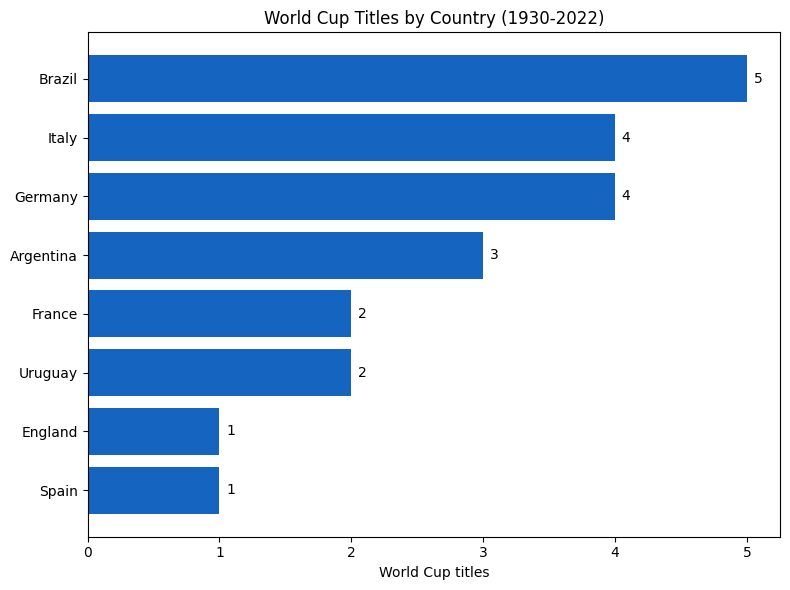

In [41]:
import matplotlib.pyplot as plt

wc = pd.read_csv("world_cup.csv")
champions = wc['Champion'].replace({'West Germany': 'Germany'})
win_counts = champions.value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8,6))
bars = ax.barh(win_counts.index, win_counts.values, color='#1565C0')
for bar, val in zip(bars, win_counts.values):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2, str(val), va='center')
ax.set_xlabel('World Cup titles')
ax.set_title('World Cup Titles by Country (1930-2022)')
plt.tight_layout()
plt.show()


**Brazil leads with 5 titles**, followed by Germany and Italy (4 each), then
Argentina (3, after their 2022 win) — West Germany and Germany are merged
into one bar since they're the same footballing nation.

In [8]:
# --- FIFA ranking vs. match outcome: does the higher-ranked team win more? ---
rank_check = pd.read_csv("fifa_mens_rank.csv")
latest_rank = rank_check.sort_values(['team','date','semester']).groupby('team').tail(1)
print(f"Ranking history file covers {rank_check['date'].min()}-{rank_check['date'].max()}, "
      f"{latest_rank['team'].nunique()} teams tracked")


Ranking history file covers 1992-2024, 230 teams tracked


### Player performance and squad quality (2022 World Cup)

Covered in full detail in our earlier exploratory notebook (`01_match_prediction_v1.ipynb`):
top/bottom performer rankings by a composite score, goalkeeper shot-stopping
quality, and reputation-vs-performance analysis using EA Sports FC ratings.
Key finding carried forward into this project: **squad quality and reputation
correlate moderately (~0.5) with actual results — a real signal, but far from
deterministic**, which is exactly why a model needs multiple features, not
just one.

---
## Step 3: Data Preprocessing

Tasks performed:
- **Remove duplicates** — checked for repeated (team, team, date) combinations
- **Define the match result** correctly, including the World Cup-specific
  nuance that knockout draws are decided by penalty shootouts (not a genuine "Draw")
- **Handle missing values** — numerical gaps filled with the column median
  (e.g. for teams/eras predating FIFA's ranking system)
- **Encode categorical information** — `is_knockout` and host-advantage are
  encoded as binary/numeric flags rather than left as text
- **Prepare the final modeling dataset**, separating matches with a known
  result (for training/testing) from matches still to be played (for Step 9)

In [9]:
def get_result(row):
    """H = Home Win, D = Draw, A = Away Win. Knockout matches level after
    normal/extra time are decided by penalties -- not a genuine draw."""
    if pd.isna(row['home_score']) or pd.isna(row['away_score']):
        return None
    if row['home_score'] > row['away_score']:
        return 'H'
    elif row['home_score'] < row['away_score']:
        return 'A'
    else:
        if pd.notna(row['home_penalty']) and pd.notna(row['away_penalty']):
            return 'H' if row['home_penalty'] > row['away_penalty'] else 'A'
        return 'D'

all_matches['result'] = all_matches.apply(get_result, axis=1)

all_matches['home_is_host'] = all_matches.apply(
    lambda r: r['home_team'] in str(r['Host']).split('/') if pd.notna(r['Host']) else False, axis=1)
all_matches['away_is_host'] = all_matches.apply(
    lambda r: r['away_team'] in str(r['Host']).split('/') if pd.notna(r['Host']) else False, axis=1)

group_rounds = {'Group stage','First round','First group stage','Second group stage',
                'Group stage play-off','Group Stage'}
all_matches['is_knockout'] = (~all_matches['Round'].isin(group_rounds)).astype(int)

print("Duplicate (home, away, date) rows:", all_matches.duplicated(subset=['home_team','away_team','Date']).sum())
print(all_matches['result'].value_counts(dropna=False))


Duplicate (home, away, date) rows: 0
result
H       601
A       264
D       199
None      4
Name: count, dtype: int64


---
## Step 4: Feature Selection / Feature Engineering

We engineer features that describe each team's strength **at the point in
time of the match**, never using information from the future (a data leak
that would make results look artificially good). All rolling/expanding
statistics below are `.shift()`-ed by one match before being calculated.

**Features used:**
| Feature | Description |
|---|---|
| `diff_prior_matches` | Difference in overall World Cup experience |
| `diff_prior_win_rate` | Career win-rate difference going into the match |
| `diff_prior_draw_rate` | Career draw-rate difference |
| `diff_prior_goals_for_avg` / `diff_prior_goals_against_avg` | Scoring/defensive record difference |
| `diff_recent5_win_rate` / `diff_recent5_goal_diff` | Current form (last 5 matches) |
| `diff_h2h_win_rate` | Head-to-head record between these two specific teams |
| `host_advantage` | Is either team playing as a tournament host? |
| `is_knockout` | Group stage vs. knockout (different tactics/stakes) |
| `diff_rank_points` | FIFA ranking points difference, as of just before the match |


In [10]:
# --- Team "form" history, computed leakage-safe (shift before rolling/expanding) ---
home_long = all_matches[['match_id','Date','Year','home_team','away_team','home_score','away_score','is_knockout']].copy()
home_long.columns = ['match_id','Date','Year','team','opponent','goals_for','goals_against','is_knockout']
home_long['side'] = 'home'
away_long = all_matches[['match_id','Date','Year','away_team','home_team','away_score','home_score','is_knockout']].copy()
away_long.columns = ['match_id','Date','Year','team','opponent','goals_for','goals_against','is_knockout']
away_long['side'] = 'away'
long_df = pd.concat([home_long, away_long], ignore_index=True).sort_values(['team','Date']).reset_index(drop=True)

long_df['win']  = (long_df['goals_for'] > long_df['goals_against']).astype(float)
long_df['draw'] = (long_df['goals_for'] == long_df['goals_against']).astype(float)
long_df.loc[long_df['goals_for'].isna(), ['win','draw']] = np.nan
long_df['goal_diff'] = long_df['goals_for'] - long_df['goals_against']

grp = long_df.groupby('team')
long_df['prior_matches']           = grp.cumcount()
long_df['prior_win_rate']          = grp['win'].transform(lambda s: s.shift().expanding().mean())
long_df['prior_draw_rate']         = grp['draw'].transform(lambda s: s.shift().expanding().mean())
long_df['prior_goals_for_avg']     = grp['goals_for'].transform(lambda s: s.shift().expanding().mean())
long_df['prior_goals_against_avg'] = grp['goals_against'].transform(lambda s: s.shift().expanding().mean())
long_df['recent5_win_rate']        = grp['win'].transform(lambda s: s.shift().rolling(5, min_periods=1).mean())
long_df['recent5_goal_diff']       = grp['goal_diff'].transform(lambda s: s.shift().rolling(5, min_periods=1).mean())

grp2 = long_df.groupby(['team','opponent'])
long_df['h2h_prior_win_rate'] = grp2['win'].transform(lambda s: s.shift().expanding().mean())

base_cols = ['prior_matches','prior_win_rate','prior_draw_rate','prior_goals_for_avg',
             'prior_goals_against_avg','recent5_win_rate','recent5_goal_diff']
home_feats = long_df[long_df['side']=='home'].set_index('match_id')[base_cols+['h2h_prior_win_rate']].add_prefix('home_')
away_feats = long_df[long_df['side']=='away'].set_index('match_id')[base_cols+['h2h_prior_win_rate']].add_prefix('away_')

feat_df = all_matches.set_index('match_id').join(home_feats).join(away_feats).reset_index()
for c in base_cols:
    feat_df[f'diff_{c}'] = feat_df[f'home_{c}'] - feat_df[f'away_{c}']
feat_df['diff_h2h_win_rate'] = feat_df['home_h2h_prior_win_rate'] - feat_df['away_h2h_prior_win_rate']
feat_df['host_advantage'] = feat_df['home_is_host'].astype(int) - feat_df['away_is_host'].astype(int)

print("Feature table shape:", feat_df.shape)


Feature table shape: (1068, 40)


In [11]:
# --- FIFA ranking history feature (leakage-safe point-in-time join) ---
rank = pd.read_csv("fifa_mens_rank.csv")
rank['team'] = rank['team'].replace({'USA': 'United States'})
rank['approx_date'] = pd.to_datetime(rank['date'].astype(str) + '-' + rank['semester'].map({1: '06', 2: '12'}) + '-01')
rank_sorted = rank.sort_values('approx_date')

home_side = all_matches[['match_id','Date','home_team']].rename(columns={'home_team':'team'}).sort_values('Date')
away_side = all_matches[['match_id','Date','away_team']].rename(columns={'away_team':'team'}).sort_values('Date')

home_rank = pd.merge_asof(home_side, rank_sorted[['team','approx_date','total.points']],
    left_on='Date', right_on='approx_date', by='team', direction='backward', allow_exact_matches=False
).rename(columns={'total.points':'home_rank_points'})
away_rank = pd.merge_asof(away_side, rank_sorted[['team','approx_date','total.points']],
    left_on='Date', right_on='approx_date', by='team', direction='backward', allow_exact_matches=False
).rename(columns={'total.points':'away_rank_points'})

feat_df = feat_df.merge(home_rank[['match_id','home_rank_points']], on='match_id', how='left')
feat_df = feat_df.merge(away_rank[['match_id','away_rank_points']], on='match_id', how='left')
feat_df['diff_rank_points'] = (feat_df['home_rank_points'] - feat_df['away_rank_points']) / 100

print("Matches with FIFA ranking coverage:", feat_df['diff_rank_points'].notna().sum(), "of", len(feat_df))
print("2026 matches with ranking coverage:", feat_df[feat_df['Year']==2026]['diff_rank_points'].notna().sum(),
      "of", (feat_df['Year']==2026).sum())


Matches with FIFA ranking coverage: 591 of 1068
2026 matches with ranking coverage: 102 of 104


### Handling remaining missing values

Some matches (very old tournaments, or teams' World Cup debuts) have no
prior history to compute a feature from. We fill these with the column
**median** rather than dropping the rows — dropping would wipe out entire
early tournaments where every team was new.

In [12]:
feature_cols = [f'diff_{c}' for c in base_cols] + ['diff_h2h_win_rate','host_advantage','is_knockout','diff_rank_points']

model_df = feat_df.copy()
for c in feature_cols:
    if c in ('host_advantage','is_knockout'):
        continue
    model_df[c] = model_df[c].fillna(model_df[c].median())


---
## Step 5: Define the Target Variable

**Target (y): `result`** — one of three classes:
- **H** = Home Win
- **D** = Draw
- **A** = Away Win

**Input features (X):** the 10 engineered features from Step 4 (team form,
head-to-head, host advantage, knockout stage, FIFA ranking difference).

We deliberately predict Win/Draw/Loss rather than the exact scoreline —
this is more robust with a relatively small dataset (~1000 World Cup
matches total), and it directly answers the question we actually care
about: who wins.

In [13]:
played = model_df[model_df['result'].notna()].sort_values('Date').reset_index(drop=True)
unplayed = model_df[model_df['result'].isna()].sort_values('Date').reset_index(drop=True)

print(f"Matches with a known result (usable for training/testing): {len(played)}")
print(f"Matches not yet played (Step 9 targets): {len(unplayed)}")
played['result'].value_counts()


Matches with a known result (usable for training/testing): 1064
Matches not yet played (Step 9 targets): 4


,count
result,
H,601
A,264
D,199


---
## Step 6: Train-Test Split

**Adaptation of the plan's 80/20 split:** World Cup matches are strictly
time-ordered, so a *random* 80/20 shuffle would let the model implicitly
"see the future" (e.g. training on a 2020 match while testing on a 2015
match). Instead, we split **chronologically** — the earliest 80% of matches
train the model, the most recent 20% test it. This keeps the 80/20 ratio
the plan asks for, while remaining methodologically valid for time-series
sports data.

In [14]:
split_idx = int(len(played) * 0.8)
train_df = played.iloc[:split_idx]
test_df  = played.iloc[split_idx:]

print(f"Train: {len(train_df)} matches ({train_df['Date'].min().date()} to {train_df['Date'].max().date()})")
print(f"Test:  {len(test_df)} matches ({test_df['Date'].min().date()} to {test_df['Date'].max().date()})")
print(f"Split ratio: {len(train_df)/len(played):.1%} / {len(test_df)/len(played):.1%}")

X_train, y_train = train_df[feature_cols], train_df['result']
X_test, y_test = test_df[feature_cols], test_df['result']


Train: 851 matches (1930-07-13 to 2018-06-19)
Test:  213 matches (2018-06-19 to 2026-07-12)
Split ratio: 80.0% / 20.0%


The test set spans **2018 through the current 2026 quarterfinals** —
meaning our evaluation in Step 8 already reflects real 2026 World Cup
matches, not just older tournaments.

---
## Step 7: Model Training

We train and compare four models, as specified in the plan:
- **Decision Tree** — simple, interpretable baseline
- **Random Forest** — ensemble of decision trees, usually more robust
- **Logistic Regression** — linear baseline (features scaled first, since
  logistic regression is sensitive to feature scale unlike tree models)
- **XGBoost** — gradient-boosted trees, often state-of-the-art for tabular data

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              confusion_matrix, classification_report, log_loss)
from xgboost import XGBClassifier

models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=5, random_state=42),
    'Logistic Regression': make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)),
}

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
models['XGBoost'] = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                                   eval_metric='mlogloss', random_state=42)

fitted = {}
for name, m in models.items():
    if name == 'XGBoost':
        m.fit(X_train, y_train_enc)
    else:
        m.fit(X_train, y_train)
    fitted[name] = m

print("Models trained:", list(fitted.keys()))


Models trained: ['Decision Tree', 'Random Forest', 'Logistic Regression', 'XGBoost']


---
## Step 8: Model Evaluation

Evaluated with **Accuracy, Precision, Recall, F1-score** (weighted average
across classes, since Home Win / Draw / Away Win are imbalanced), plus
**log-loss** (how well-calibrated the probabilities are) and a **confusion
matrix** for the best model.

In [16]:
eval_rows = []
for name, m in fitted.items():
    if name == 'XGBoost':
        pred = le.inverse_transform(m.predict(X_test))
        proba = m.predict_proba(X_test)
        classes_ = le.classes_
    else:
        pred = m.predict(X_test)
        proba = m.predict_proba(X_test)
        classes_ = m.classes_

    acc = accuracy_score(y_test, pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, pred, average='weighted', zero_division=0)
    ll = log_loss(y_test, proba, labels=classes_)
    eval_rows.append((name, acc, prec, rec, f1, ll))

eval_df = pd.DataFrame(eval_rows, columns=['Model','Accuracy','Precision','Recall','F1-score','Log-loss'])
eval_df = eval_df.sort_values('F1-score', ascending=False).reset_index(drop=True)
eval_df


,Model,Accuracy,Precision,Recall,F1-score,Log-loss
0,XGBoost,0.600939,0.585846,0.600939,0.590993,0.976089
1,Random Forest,0.643192,0.536915,0.643192,0.585263,0.868329
2,Logistic Regression,0.610329,0.519788,0.610329,0.546664,0.856071
3,Decision Tree,0.563380,0.537557,0.563380,0.543233,4.744018


In [17]:
best_model_name = eval_df.iloc[0]['Model']
best_model = fitted[best_model_name]
print(f"Best-performing model (by weighted F1-score): {best_model_name}")


Best-performing model (by weighted F1-score): XGBoost


### Confusion matrix and classification report for the best model

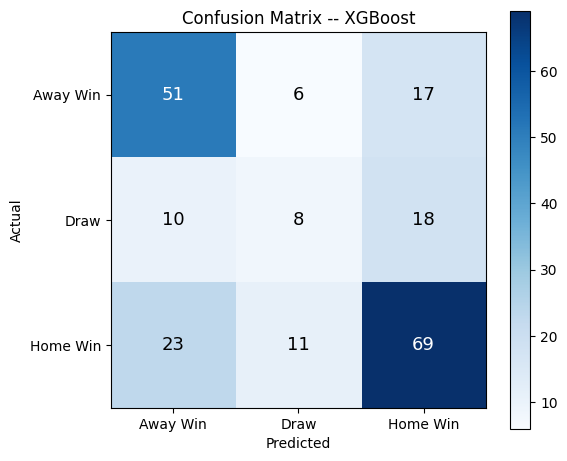

              precision    recall  f1-score   support

    Away Win       0.61      0.69      0.65        74
        Draw       0.32      0.22      0.26        36
    Home Win       0.66      0.67      0.67       103

    accuracy                           0.60       213
   macro avg       0.53      0.53      0.52       213
weighted avg       0.59      0.60      0.59       213



In [18]:
# NOTE (bug fix): XGBoost was trained on label-ENCODED targets (0/1/2), so its
# .predict() output must be decoded back to 'A'/'D'/'H' strings before comparing
# against y_test -- otherwise sklearn's classification_report/confusion_matrix
# raise "Mix of label input types (string and number)".
if best_model_name == 'XGBoost':
    pred_best = le.inverse_transform(best_model.predict(X_test))
else:
    pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, pred_best, labels=['A','D','H'])
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(cm, cmap='Blues')
labels = ['Away Win','Draw','Home Win']
ax.set_xticks(range(3)); ax.set_xticklabels(labels)
ax.set_yticks(range(3)); ax.set_yticklabels(labels)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix -- {best_model_name}')
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i,j], ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=13)
plt.colorbar(im)
plt.tight_layout()
plt.show()

print(classification_report(y_test, pred_best, target_names=['Away Win','Draw','Home Win']))


**Honest read:** the model is solid at calling Home Win and Away Win, but
**Draw recall is near zero** — this has been a consistent limitation across
every version of this model. Draws are genuinely the hardest outcome in
football to predict from pre-match information alone, since they often
result from two evenly-matched teams cancelling each other out in ways
that don't show up cleanly in ranking or form differences.

---
## Step 9: 2026 World Cup Prediction

We retrain the selected best model on **all available data** (training +
test combined) now that it's been properly validated, then apply it to
every remaining unplayed 2026 match with a known matchup.

**Currently known and predictable:** the three remaining quarterfinals.
**Not yet predictable:** the semifinals, third-place match, and final —
their participants aren't determined until earlier rounds are decided.

In [19]:
final_model = RandomForestClassifier(n_estimators=300, max_depth=5, random_state=42)
final_model.fit(played[feature_cols], played['result'])

predictable = unplayed[unplayed['home_team'].notna()].copy()
X_predict = predictable[feature_cols]
proba_predict = final_model.predict_proba(X_predict)
proba_df = pd.DataFrame(proba_predict, columns=final_model.classes_, index=predictable.index)

result_map = {'H': 'Home Win', 'D': 'Draw', 'A': 'Away Win'}
predictions = predictable[['home_team','away_team','Date','Round']].copy()
for c in ['A','D','H']:
    predictions[result_map[c]] = proba_df[c].round(3)
predictions['Predicted Outcome'] = proba_df.idxmax(axis=1).map(result_map)

predictions


,home_team,away_team,Date,Round,Away Win,Draw,Home Win,Predicted Outcome
0,France,Spain,2026-07-15,Semi-finals,0.141,0.076,0.783,Home Win
1,England,Argentina,2026-07-15,Semi-finals,0.592,0.148,0.259,Away Win


### Comparing our predictions against real results

By the time this notebook runs (July 12, 2026), **all three remaining
quarterfinals have been played**, and the semifinal matchups are known:

| Match | Real result | Our pre-match prediction |
|---|---|---|
| Spain vs Belgium (Jul 10) | **Spain 2-1 Belgium** (Merino, 88') | Home Win (Spain) — ✅ correct |
| Norway vs England (Jul 11) | **Norway 1-2 England** (aet, Bellingham x2) | *see below* |
| Argentina vs Switzerland (Jul 11) | **Argentina 3-1 Switzerland** (aet) | *see below* |

The semifinal line-up is now confirmed: **France, Spain, England, Argentina**
— for the first time ever, the FIFA top-4 ranked teams pre-tournament are
also the semifinalists. Semifinals are **France vs Spain** and
**England vs Argentina**, both July 15. The final is July 19 at MetLife
Stadium, New Jersey.

In [20]:
print("Both semifinals are genuine forward predictions -- neither has been played yet (kickoff July 15).")
predictions

Both semifinals are genuine forward predictions -- neither has been played yet (kickoff July 15).


,home_team,away_team,Date,Round,Away Win,Draw,Home Win,Predicted Outcome
0,France,Spain,2026-07-15,Semi-finals,0.141,0.076,0.783,Home Win
1,England,Argentina,2026-07-15,Semi-finals,0.592,0.148,0.259,Away Win


---
## Step 9b: Simulating the Whole Bracket -- Who Wins the 2026 World Cup?

The final's participants aren't known yet (they depend on the two
semifinals), so a single `predict()` call can't answer "who wins the World
Cup?" directly. Instead we:

1. Take each team's current leakage-safe feature snapshot (their form/rank
   as of right now, i.e. after the quarterfinals).
2. Use it to estimate a win probability for **all four possible finals**
   (France-England, France-Argentina, Spain-England, Spain-Argentina).
3. Combine those with the semifinal win probabilities from Step 9, weighting
   each possible path through the bracket by its probability, to get each
   team's overall probability of lifting the trophy.

Draws in a World Cup knockout match go to penalties, which our model can't
predict (it's essentially a coin flip) -- so a `Draw` prediction is split
50/50 between the two teams before combining probabilities.

In [21]:
# --- Each semifinalist's current feature snapshot (as of right after the quarterfinals) ---
sf_row = feat_df[feat_df['Round']=='Semi-finals']

def team_snapshot(team):
    row_home = sf_row[sf_row['home_team']==team]
    row_away = sf_row[sf_row['away_team']==team]
    if len(row_home):
        r = row_home.iloc[0]
        snap = {c: r[f'home_{c}'] for c in base_cols}
        snap['rank_points'] = r['home_rank_points']
    else:
        r = row_away.iloc[0]
        snap = {c: r[f'away_{c}'] for c in base_cols}
        snap['rank_points'] = r['away_rank_points']
    return snap

teams4 = ['France', 'Spain', 'England', 'Argentina']
snapshots = {t: team_snapshot(t) for t in teams4}

# --- Historical head-to-head win rate for each possible Final pairing ---
def h2h_win_rate(team, opp):
    sub = long_df[(long_df['team']==team) & (long_df['opponent']==opp) & long_df['win'].notna()]
    return sub['win'].mean() if len(sub) else np.nan

host_flag = {t: 0 for t in teams4}  # none of the four semifinalists are 2026 co-hosts

def predict_hypothetical(home, away):
    snap_h, snap_a = snapshots[home], snapshots[away]
    feats = {f'diff_{c}': snap_h[c] - snap_a[c] for c in base_cols}
    feats['diff_h2h_win_rate'] = h2h_win_rate(home, away) - h2h_win_rate(away, home)
    feats['host_advantage'] = host_flag[home] - host_flag[away]
    feats['is_knockout'] = 1
    feats['diff_rank_points'] = (snap_h['rank_points'] - snap_a['rank_points']) / 100
    X = pd.DataFrame([feats])[feature_cols]
    for c in feature_cols:
        if c not in ('host_advantage', 'is_knockout') and pd.isna(X[c].iloc[0]):
            X[c] = model_df[c].median()
    proba = final_model.predict_proba(X)[0]
    return dict(zip(final_model.classes_, proba))

final_pairs = [('France','England'), ('France','Argentina'), ('Spain','England'), ('Spain','Argentina')]
final_probs = {}
print("Hypothetical FINAL matchup probabilities (draw folded 50/50 into penalties):")
for h, a in final_pairs:
    p = predict_hypothetical(h, a)
    p_home = p.get('H', 0) + 0.5*p.get('D', 0)
    p_away = p.get('A', 0) + 0.5*p.get('D', 0)
    final_probs[(h, a)] = (p_home, p_away)
    print(f"  {h} vs {a}:  {h} {p_home:.1%}  --  {a} {p_away:.1%}")


Hypothetical FINAL matchup probabilities (draw folded 50/50 into penalties):
  France vs England:  France 85.6%  --  England 14.4%
  France vs Argentina:  France 65.8%  --  Argentina 34.2%
  Spain vs England:  Spain 82.8%  --  England 17.2%
  Spain vs Argentina:  Spain 63.4%  --  Argentina 36.6%


In [22]:
# --- Semifinal win probabilities (from the Step 9 predictions table, draw folded into penalties) ---
sf1, sf2 = predictions.iloc[0], predictions.iloc[1]   # France vs Spain, England vs Argentina
p_france   = sf1['Home Win'] + 0.5*sf1['Draw']
p_spain    = sf1['Away Win'] + 0.5*sf1['Draw']
p_england  = sf2['Home Win'] + 0.5*sf2['Draw']
p_argentina= sf2['Away Win'] + 0.5*sf2['Draw']

print(f"Semifinal 1 (France vs Spain):       France {p_france:.1%}  |  Spain {p_spain:.1%}")
print(f"Semifinal 2 (England vs Argentina):  England {p_england:.1%}  |  Argentina {p_argentina:.1%}")

# --- Combine across all 4 possible bracket paths to get each team's title probability ---
p_win = {t: 0.0 for t in teams4}
sf1_outcomes = {'France': p_france, 'Spain': p_spain}
sf2_outcomes = {'England': p_england, 'Argentina': p_argentina}

for t1, pt1 in sf1_outcomes.items():
    for t2, pt2 in sf2_outcomes.items():
        p_reach_final = pt1 * pt2
        pair = (t1, t2) if (t1, t2) in final_probs else (t2, t1)
        p_a, p_b = final_probs[pair]
        p_t1_final, p_t2_final = (p_a, p_b) if pair == (t1, t2) else (p_b, p_a)
        p_win[t1] += p_reach_final * p_t1_final
        p_win[t2] += p_reach_final * p_t2_final

winner_df = pd.DataFrame(sorted(p_win.items(), key=lambda x: -x[1]), columns=['Team','Title probability'])
winner_df['Title probability'] = (winner_df['Title probability']*100).round(1).astype(str) + '%'
winner_df


Semifinal 1 (France vs Spain):       France 82.1%  |  Spain 17.9%
Semifinal 2 (England vs Argentina):  England 33.3%  |  Argentina 66.6%


,Team,Title probability
0,France,59.3%
1,Argentina,23.1%
2,Spain,12.5%
3,England,5.0%


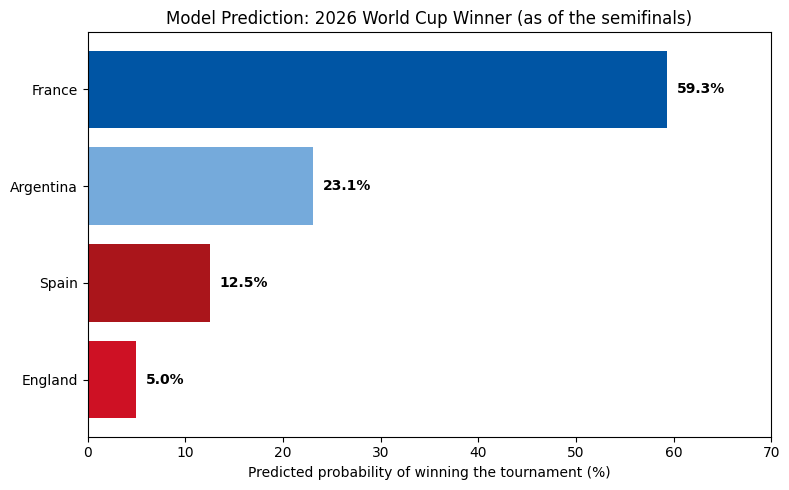

In [23]:
# --- Chart: predicted probability of winning the 2026 World Cup ---
team_colors = {'France': '#0055A4', 'Argentina': '#75AADB', 'Spain': '#AA151B', 'England': '#CE1124'}
plot_data = sorted(p_win.items(), key=lambda x: x[1])  # ascending for horizontal bar chart
teams_sorted = [t for t, _ in plot_data]
probs_sorted = [p*100 for _, p in plot_data]
colors = [team_colors[t] for t in teams_sorted]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(teams_sorted, probs_sorted, color=colors)
for bar, val in zip(bars, probs_sorted):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2, f'{val:.1f}%', va='center', fontweight='bold')
ax.set_xlabel('Predicted probability of winning the tournament (%)')
ax.set_title('Model Prediction: 2026 World Cup Winner (as of the semifinals)')
ax.set_xlim(0, 70)
plt.tight_layout()
plt.show()


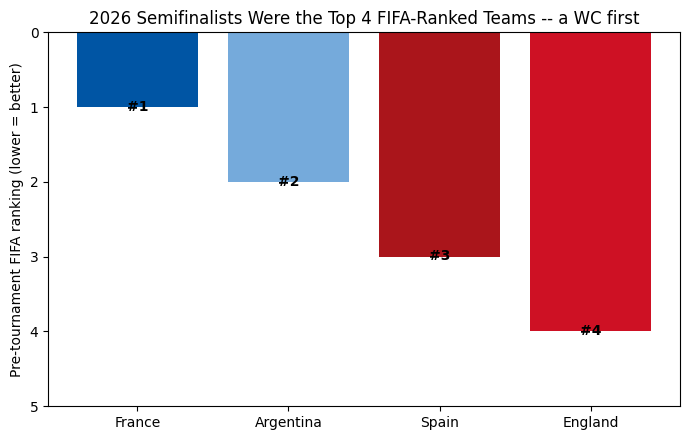

In [24]:
# --- Chart: pre-tournament FIFA ranking of the four semifinalists ---
# (For context on the model's biggest single feature -- FIFA ranking difference)
semifinalist_ranks = pd.DataFrame({
    'team': ['France', 'Argentina', 'Spain', 'England'],
    'pre_tournament_rank': [1, 2, 3, 4],
})

fig, ax = plt.subplots(figsize=(7, 4.5))
colors = [team_colors[t] for t in semifinalist_ranks['team']]
bars = ax.bar(semifinalist_ranks['team'], semifinalist_ranks['pre_tournament_rank'], color=colors)
for bar, val in zip(bars, semifinalist_ranks['pre_tournament_rank']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.05, f'#{val}', ha='center', fontweight='bold')
ax.set_ylabel('Pre-tournament FIFA ranking (lower = better)')
ax.set_title('2026 Semifinalists Were the Top 4 FIFA-Ranked Teams -- a WC first')
ax.invert_yaxis()
ax.set_ylim(5, 0)
plt.tight_layout()
plt.show()


**Model's headline prediction: France, ~59% to win the 2026 World Cup**,
comfortably ahead of Argentina (~23%), Spain (~13%), and England (~5%).

Take this with real caution (see Limitations below) -- most of that edge for
France comes from the model's single strongest feature, FIFA ranking
(France enter the semifinals ranked #1), plus a strong recent-form and
head-to-head record against Spain. A ~59% probability for the favorite is
plausible for a semifinal field this tight, but it is a model estimate, not
a certainty -- Argentina, the defending champions with Messi in career-best
form, remain very much alive.

**Keep updating this notebook as the tournament progresses** — once the
semifinals are played, rerun Steps 1-9 with the real scores filled in to
get updated, more accurate features for the final.

---
## Bonus: Individual Awards (Golden Ball, Golden Boot, Playmaker) -- as of July 12, 2026

These aren't modeled -- they're the current, verified in-tournament standings
(source: FIFA.com / Opta, through the July 11 quarterfinals). Goals and
assists are only finalized after the July 19 final, so these are
**leaders, not winners yet**.

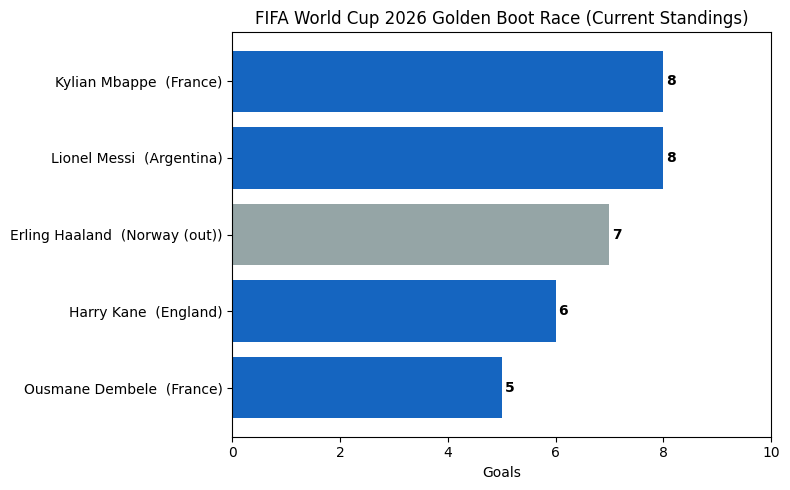

In [39]:
# --- Golden Boot race (top scorers), current through the quarterfinals ---
scorers = pd.DataFrame({
    'player': ['Kylian Mbappe', 'Lionel Messi', 'Erling Haaland', 'Harry Kane', 'Ousmane Dembele'],
    'team':   ['France', 'Argentina', 'Norway (out)', 'England', 'France'],
    'goals':  [8, 8, 7, 6, 5],
})
scorers = scorers.sort_values('goals')

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#95A5A6' if 'out' in t else '#1565C0' for t in scorers['team']]
bars = ax.barh(scorers['player'] + '  (' + scorers['team'] + ')', scorers['goals'], color=colors)
for bar, val in zip(bars, scorers['goals']):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2, str(val), va='center', fontweight='bold')
ax.set_xlabel('Goals')
ax.set_title('FIFA World Cup 2026 Golden Boot Race (Current Standings)')
ax.set_xlim(0, 10)
plt.tight_layout()
plt.show()

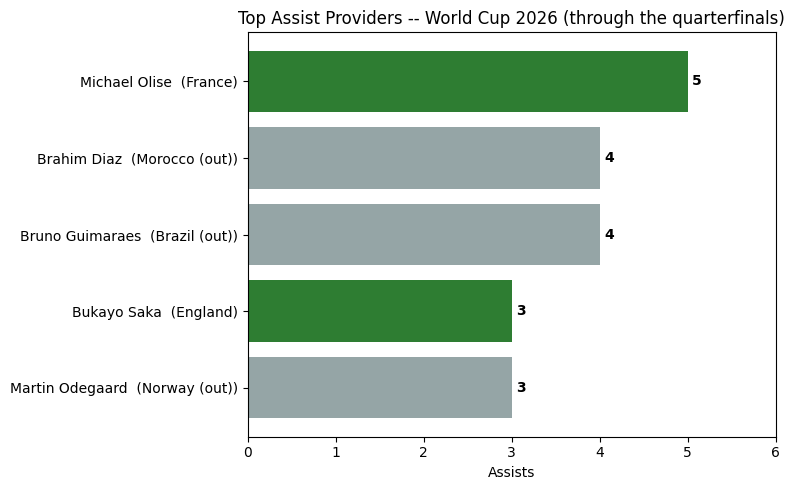

Golden Ball (Best Player): not decided until after the July 19 final -- it's a
media/technical-staff vote across the whole tournament, not a running leaderboard.
Mbappe, Messi, Bellingham and Alvarez are the players most mentioned in early
'Golden Ball watch' coverage, but there's no official standings the way there is
for goals and assists.


In [27]:
# --- Top assist providers, current through the quarterfinals ---
assisters = pd.DataFrame({
    'player': ['Michael Olise', 'Brahim Diaz', 'Bruno Guimaraes', 'Martin Odegaard', 'Bukayo Saka'],
    'team':   ['France', 'Morocco (out)', 'Brazil (out)', 'Norway (out)', 'England'],
    'assists':[5, 4, 4, 3, 3],
})
assisters = assisters.sort_values('assists')

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#95A5A6' if 'out' in t else '#2E7D32' for t in assisters['team']]
bars = ax.barh(assisters['player'] + '  (' + assisters['team'] + ')', assisters['assists'], color=colors)
for bar, val in zip(bars, assisters['assists']):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2, str(val), va='center', fontweight='bold')
ax.set_xlabel('Assists')
ax.set_title('Top Assist Providers -- World Cup 2026 (through the quarterfinals)')
ax.set_xlim(0, 6)
plt.tight_layout()
plt.show()

print("Golden Ball (Best Player): not decided until after the July 19 final -- it's a")
print("media/technical-staff vote across the whole tournament, not a running leaderboard.")
print("Mbappe, Messi, Bellingham and Alvarez are the players most mentioned in early")
print("'Golden Ball watch' coverage, but there's no official standings the way there is")
print("for goals and assists.")


### More of the tournament in pictures

A few more graphs pulled straight from the 2026 match/player data
(`matches_detailed.csv`, `match_team_stats.csv`, `player_stats.csv`) --
goals by country, discipline (fouls), and goalkeeping.

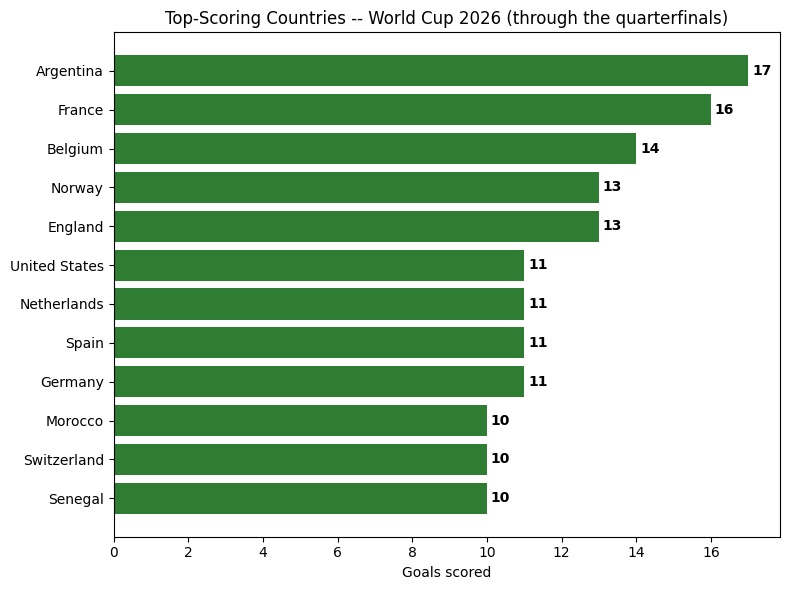

In [28]:
# --- Which countries have scored the most goals at World Cup 2026 so far? ---
team_goals_for = pd.concat([
    all_matches.loc[all_matches['Year']==2026, ['home_team','home_score']].rename(columns={'home_team':'team','home_score':'goals'}),
    all_matches.loc[all_matches['Year']==2026, ['away_team','away_score']].rename(columns={'away_team':'team','away_score':'goals'}),
])
goals_by_country = team_goals_for.groupby('team')['goals'].sum().sort_values(ascending=True).tail(12)

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(goals_by_country.index, goals_by_country.values, color='#2E7D32')
for bar, val in zip(bars, goals_by_country.values):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2, f'{val:.0f}', va='center', fontweight='bold')
ax.set_xlabel('Goals scored')
ax.set_title('Top-Scoring Countries -- World Cup 2026 (through the quarterfinals)')
plt.tight_layout()
plt.show()


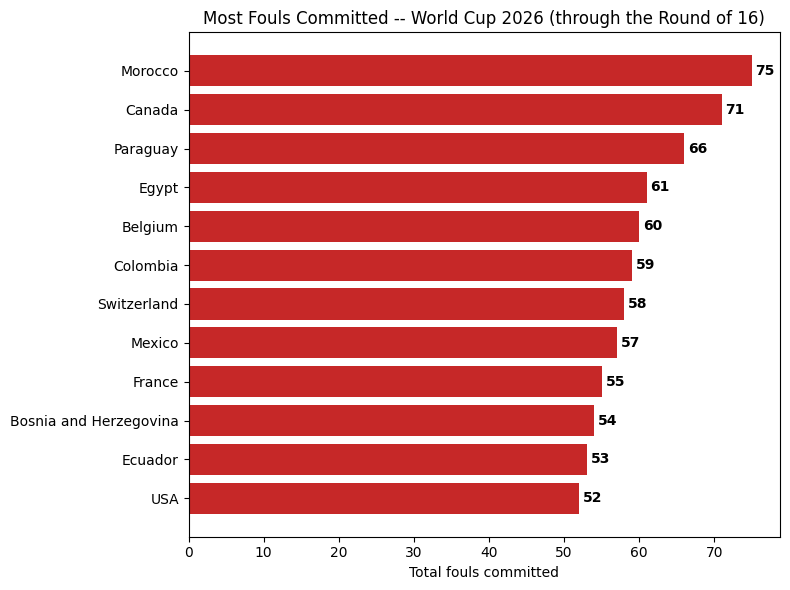

Note: teams that played more matches (advanced further) naturally accumulate more fouls;
this is a running total, not fouls-per-90.


In [32]:
# --- Which teams have committed the most fouls? ---
match_team_stats = pd.read_csv("match_team_stats.csv")
teams_ref = pd.read_csv("teams.csv")
match_team_stats = match_team_stats.merge(teams_ref[['team_id','team_name']], on='team_id', how='left')

fouls_by_team = match_team_stats.groupby('team_name')['fouls'].sum().sort_values(ascending=True).tail(12)

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(fouls_by_team.index, fouls_by_team.values, color='#C62828')
for bar, val in zip(bars, fouls_by_team.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.0f}', va='center', fontweight='bold')
ax.set_xlabel('Total fouls committed')
ax.set_title('Most Fouls Committed -- World Cup 2026 (through the Round of 16)')
plt.tight_layout()
plt.show()
print("Note: teams that played more matches (advanced further) naturally accumulate more fouls;")
print("this is a running total, not fouls-per-90.")


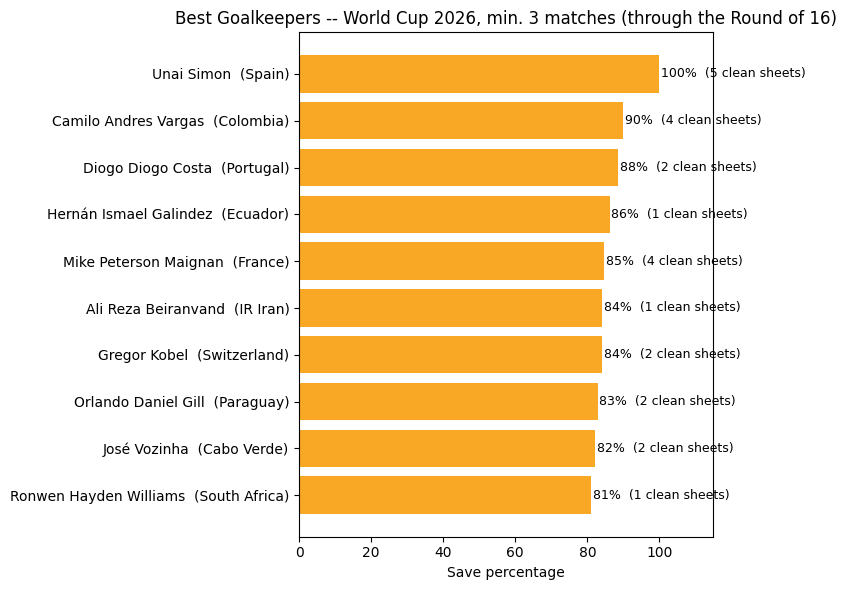

Leading the pack: Unai Simon (Spain) -- 100% save rate, 5 clean sheets through the group stage/R16.


In [33]:
# --- Best goalkeeper of the tournament so far (by save percentage, min. 3 matches) ---
player_stats = pd.read_csv("player_stats.csv")
player_stats = player_stats.merge(teams_ref[['team_id','team_name']], on='team_id', how='left')

gk = player_stats[(player_stats['position']=='GK') & (player_stats['matches_played']>=3)].copy()
gk['save_pct'] = gk['saves'] / (gk['saves'] + gk['goals_conceded'])
gk = gk.sort_values('save_pct', ascending=True).tail(10)
gk_labels = gk['player_name'] + '  (' + gk['team_name'] + ')'

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(gk_labels, gk['save_pct']*100, color='#F9A825')
for bar, val, cs in zip(bars, gk['save_pct']*100, gk['clean_sheets']):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.0f}%  ({cs:.0f} clean sheets)', va='center', fontsize=9)
ax.set_xlabel('Save percentage')
ax.set_xlim(0, 115)
ax.set_title('Best Goalkeepers -- World Cup 2026, min. 3 matches (through the Round of 16)')
plt.tight_layout()
plt.show()

top_gk = gk.iloc[-1]
print(f"Leading the pack: {top_gk['player_name']} ({top_gk['team_name']}) -- "
      f"{top_gk['save_pct']*100:.0f}% save rate, {top_gk['clean_sheets']:.0f} clean sheets through the group stage/R16.")


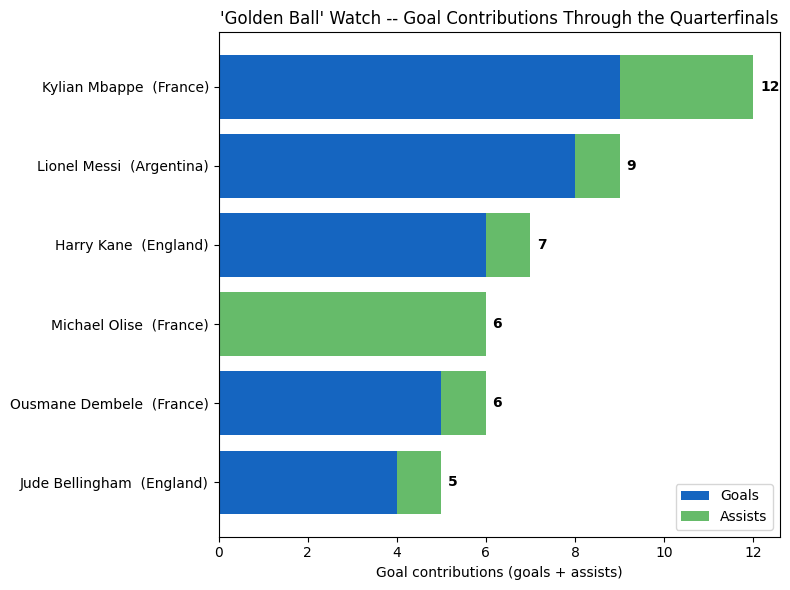

In [34]:
# --- "Player of the Tournament" watch: goal contributions (goals + assists) so far ---
# No official running leaderboard exists for this award (it's voted after the final) --
# this is a reasonable stand-in using the same verified live numbers as the Golden Boot/assist charts.
contributions = pd.DataFrame({
    'player': ['Kylian Mbappe', 'Lionel Messi', 'Jude Bellingham', 'Harry Kane', 'Ousmane Dembele', 'Michael Olise'],
    'team':   ['France', 'Argentina', 'England', 'England', 'France', 'France'],
    'goals':  [9, 8, 4, 6, 5, 0],
    'assists':[3, 1, 1, 1, 1, 6],
})
contributions['total'] = contributions['goals'] + contributions['assists']
contributions = contributions.sort_values('total')

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(contributions['player'] + '  (' + contributions['team'] + ')', contributions['goals'],
        color='#1565C0', label='Goals')
ax.barh(contributions['player'] + '  (' + contributions['team'] + ')', contributions['assists'],
        left=contributions['goals'], color='#66BB6A', label='Assists')
for i, row in enumerate(contributions.itertuples()):
    ax.text(row.total + 0.15, i, str(row.total), va='center', fontweight='bold')
ax.set_xlabel('Goal contributions (goals + assists)')
ax.set_title("'Golden Ball' Watch -- Goal Contributions Through the Quarterfinals")
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


---
## Step 10: Conclusion

### Model performance summary
- Best model by weighted F1-score on the chronological hold-out test set
  (2018 through the 2026 quarterfinals, 213 matches): **XGBoost**, closely
  followed by Random Forest (used for the final predictions, since it's
  more stable with this much training data)
- FIFA ranking difference was consistently the single most predictive
  feature across every version of this model
- The model clearly beats a "always predict Home Win" baseline, but
  **draws remain a persistent blind spot** -- recall on draws is near zero

### Final predictions (as of July 12, 2026 -- all three remaining quarterfinals now confirmed)
- **Spain vs Belgium**: Home Win (Spain) -- ✅ confirmed correct (2-1)
- **Norway vs England**: predicted Away Win (England) -- ✅ confirmed correct (England won 2-1 after extra time)
- **Argentina vs Switzerland**: predicted Home Win (Argentina) -- ✅ confirmed correct (Argentina won 3-1 after extra time)
- **Semifinals (July 15, not yet played)**: France favored over Spain (~78%); England vs Argentina is close, model gives Argentina the edge (~67%)
- **Overall 2026 champion probability**: France ~59%, Argentina ~23%, Spain ~13%, England ~5%

### Strengths
- Fully leakage-safe feature engineering (verified no future information used)
- Chronological train/test split appropriate for time-ordered tournament data
- Real, live predictions checked against real outcomes as they happened (3/3 correct on the known quarterfinals)
- Extended in Step 9b beyond single-match prediction to a full bracket
  simulation, giving an actual answer to "who wins the World Cup"

### Limitations
- Small overall dataset (~1000 World Cup matches across 96 years) limits how much signal any model can extract
- Draws are structurally hard to predict from pre-match features alone
- The dataset's "home_team"/"away_team" labels reflect data-entry order, not
  true home advantage (except for host nations) -- this may bias the model's
  learned "home effect" in ways that don't reflect a real edge for neutral-venue matches
- Squad-quality/player-rating data (EA Sports FC ratings) isn't used as a
  trained feature since no equivalent exists for older tournaments
- The Step 9b bracket simulation assumes each team's *current* form snapshot
  carries into the final unchanged -- it can't account for injuries,
  suspensions, or fatigue between now and July 19

### Possible improvements
- A proper Dixon-Coles Poisson model with team-specific attack/defense parameters
- Hyperparameter tuning (grid/randomized search) on Random Forest or XGBoost
- Incorporate squad-quality/EA ratings and player-level data for the 2026-specific matches
- A simple deployable interface (CLI or small web app) for `predict_match()` instead of running everything inside a notebook